In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv(r"../us.csv", low_memory=False)

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour

In [ ]:
# Exemple : suppression des valeurs extrêmes de Distance(mi)
Q1 = df['Distance(mi)'].quantile(0.25)
Q3 = df['Distance(mi)'].quantile(0.75)
IQR = Q3 - Q1
#Suppression des valeurs en dehors de 1.5*IQR 
df_clean = df[(df['Distance(mi)'] >= Q1 - 1.5*IQR) & (df['Distance(mi)'] <= Q3 + 1.5*IQR)]


In [ ]:
# Copier le DataFrame pour ne pas modifier l'original
df_clean = df.copy()

#  Colonnes numériques à nettoyer
cols = ['Distance(mi)', 'Visibility(mi)', 'Temperature(F)']

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    #  # Supprimer les valeurs en dehors de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

## Afficher les statistiques descriptives après nettoyag 
df_clean[['Distance(mi)','Visibility(mi)','Temperature(F)']].describe()


,Distance(mi),Visibility(mi),Temperature(F)
count,385311.000000,385311.0,385311.000000
mean,0.005340,10.0,67.152023
std,0.005224,0.0,15.411517
min,0.000000,10.0,24.400000
25%,0.000000,10.0,57.200000
50%,0.010000,10.0,68.000000
75%,0.010000,10.0,78.800000
max,0.020000,10.0,111.200000


In [ ]:
## Calcul de l'asymétrie (skew) et de l'aplatissement (kurtosis) après nettoyage

df_clean['Distance(mi)'].skew(), df_clean['Distance(mi)'].kurtosis()


(np.float64(0.11766605076644736), np.float64(-1.4082600671196595))

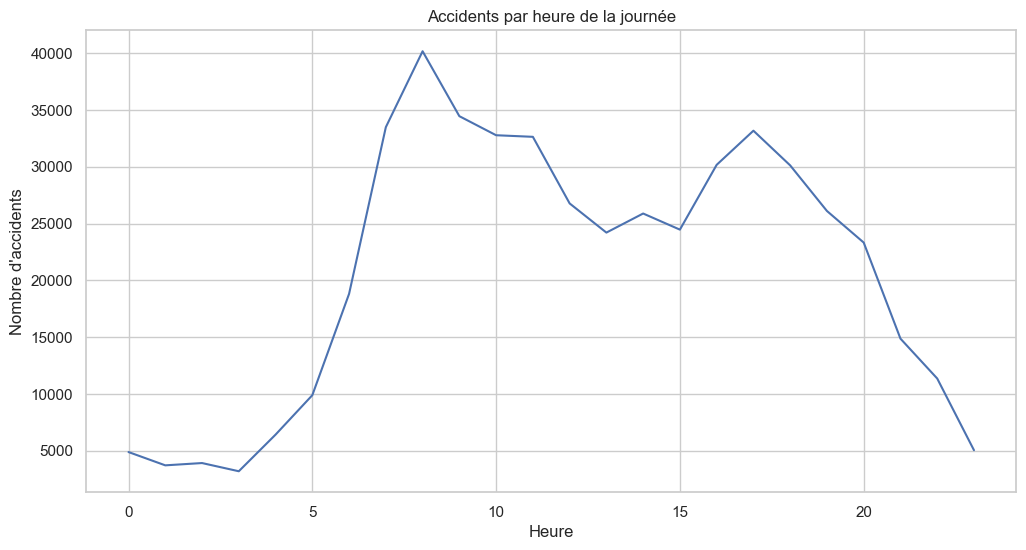

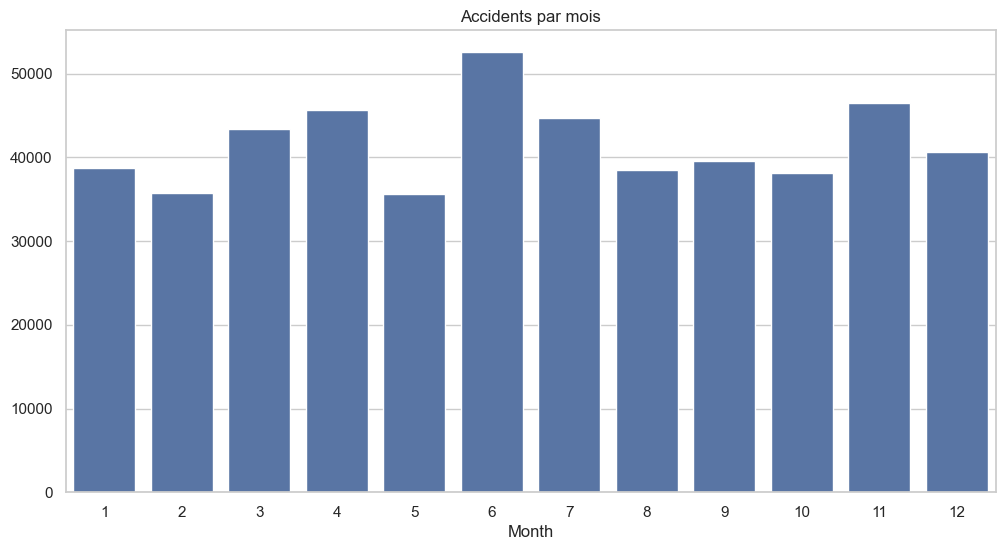

In [ ]:
# Compter le nombre d'accidents par heure
hourly = df['Hour'].value_counts().sort_index()

# Visualiser avec un graphique en ligne
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title("Accidents par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")
plt.show()

# par mois
monthly = df['Month'].value_counts().sort_index()
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Accidents par mois")
plt.show()

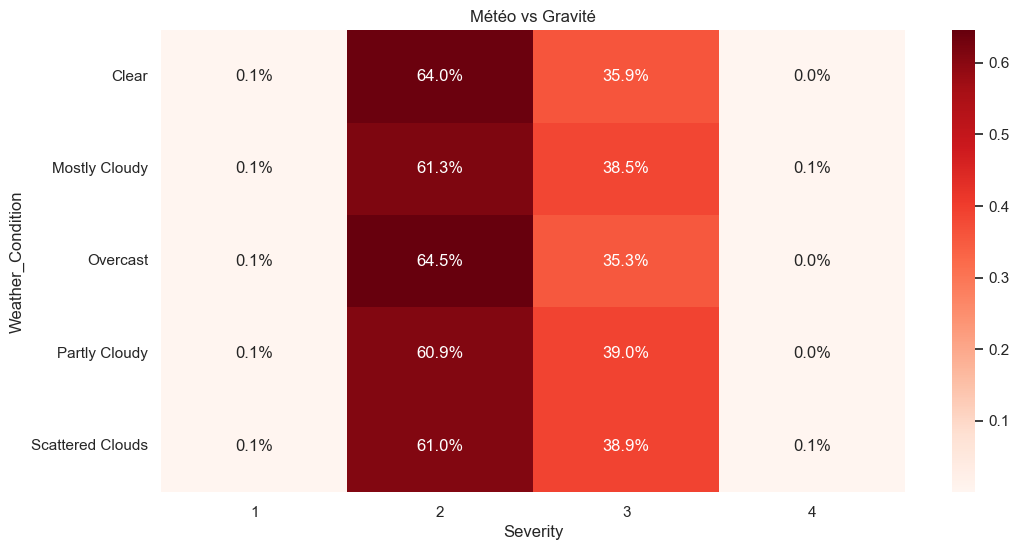

In [19]:
#Le test du Khi²
top_weather = df['Weather_Condition'].value_counts().head(5).index
df_weather = df[df['Weather_Condition'].isin(top_weather)]

table = pd.crosstab(df_weather['Weather_Condition'], df_weather['Severity'])

chi2, p, dof, expected = chi2_contingency(table)
chi2, p

sns.heatmap(
    pd.crosstab(df_weather['Weather_Condition'], df_weather['Severity'], normalize='index'),
    annot=True, fmt=".1%", cmap="Reds"
)
plt.title("Météo vs Gravité")
plt.show()

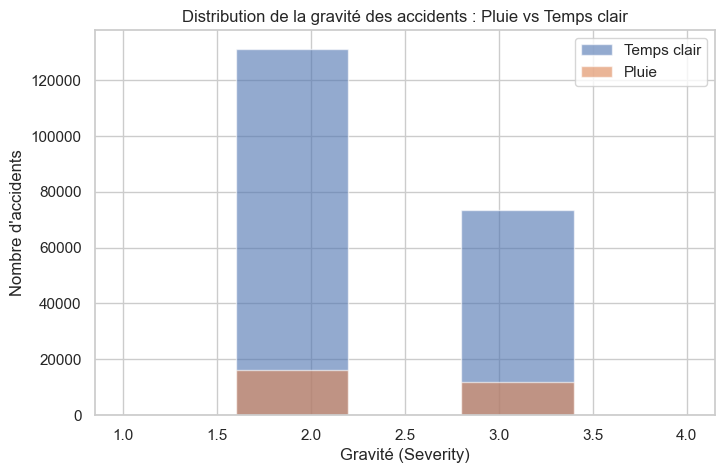

In [ ]:
#Test Mann-Whitney : Pluie vs Temps Clair
import matplotlib.pyplot as plt

rain = df[df['Weather_Condition'].str.contains('Rain', na=False)]['Severity']
clear = df[df['Weather_Condition'].str.contains('Clear', na=False)]['Severity']

stat, p = mannwhitneyu(rain, clear)
stat, p

plt.figure(figsize=(8,5))

plt.hist(clear, bins=5, alpha=0.6, label='Temps clair')
plt.hist(rain, bins=5, alpha=0.6, label='Pluie')

plt.title("Distribution de la gravité des accidents : Pluie vs Temps clair")
plt.xlabel("Gravité (Severity)")
plt.ylabel("Nombre d'accidents")
plt.legend()
plt.show()

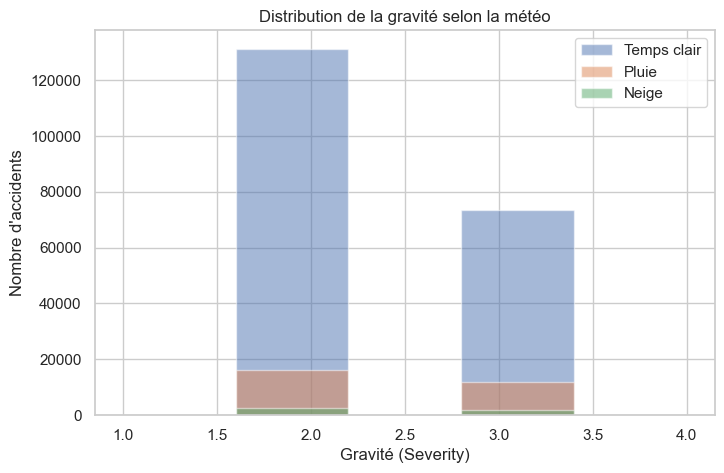

In [24]:
#ANOVA : Gravité selon météo
import matplotlib.pyplot as plt
import numpy as np

snow = df[df['Weather_Condition'].str.contains('Snow', na=False)]['Severity']

f_stat, p = f_oneway(clear, rain, snow)
f_stat, p

# Calcul des moyennes et écarts-types
means = [clear.mean(), rain.mean(), snow.mean()]
stds = [clear.std(), rain.std(), snow.std()]

labels = ['Temps clair', 'Pluie', 'Neige']

plt.figure(figsize=(8,5))
plt.hist(clear, bins=5, alpha=0.5, label='Temps clair')
plt.hist(rain, bins=5, alpha=0.5, label='Pluie')
plt.hist(snow, bins=5, alpha=0.5, label='Neige')
plt.legend()
plt.title("Distribution de la gravité selon la météo")
plt.xlabel("Gravité (Severity)")
plt.ylabel("Nombre d'accidents")
plt.show()
